# 07 - Final Evaluation & Publication-Ready Results

This notebook performs the final evaluation on the held-out test set:
1. Load the best model and selected features
2. Evaluate on untouched test data
3. Compute Bootstrap 95% Confidence Intervals
4. Generate publication-quality figures (ROC, PR, Calibration, Confusion Matrix)
5. Save all final results for the manuscript

> **Critical Rule:** Test data has been completely untouched until this point.
> All preprocessing, feature selection, and

In [28]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
from src.io import load_model, save_table, save_figure, logger
from src.models import xgb_safe_frame, requires_xgb_safe
from src.evaluation import (
    compute_metrics,
    stratified_bootstrap_auc,
    get_roc_curve_data,
    get_pr_curve_data,
    get_calibration_curve_data,
)
from src.visualization import (
    setup_style,
    plot_roc_curve,
    plot_pr_curve,
    plot_calibration,
    plot_confusion_matrix,
)
from src.pipeline import evaluate_final_model

setup_style()

## Step 1: Load Final Model and Data

In [29]:
# Load the best model (saved from Model Training notebook)
model = load_model("best_model_xgboost.joblib")
model_name = "XGBoost + PSO"

# Load selected features
selected_features_df = pd.read_csv(config.TABLES_DIR / "selected_features.csv")
selected_features = selected_features_df["feature"].tolist()

# Load preprocessed test data
X_test = pd.read_csv(config.PROCESSED_DIR / "X_test_preprocessed.csv")
y_test = pd.read_csv(config.PROCESSED_DIR / "y_test.csv").iloc[:, 0]

# Select only the final features
X_test_final = X_test[selected_features].copy()

print(f"Model: {model_name}")
print(f"Selected features: {len(selected_features)}")
print(f"Test samples: {len(X_test_final)}")
print(f"Test positive rate: {y_test.mean():.2%}")

2026-08-06 01:50:19 | INFO     | prostate_bcr | Loading model from D:\Prostate_BCR_Q1\core\outputs\models\best_model_xgboost.joblib


Model: XGBoost + PSO
Selected features: 30
Test samples: 86
Test positive rate: 13.95%


## Step 2: Final Evaluation on Held-out Test Set

This is the **only time** the test data is used for evaluation.

In [30]:
from sklearn.metrics import roc_curve

# ── Generate predictions ──
if requires_xgb_safe(model_name):
    X_eval = xgb_safe_frame(X_test_final)
else:
    X_eval = X_test_final

y_prob = model.predict_proba(X_eval)[:, 1]

# ── Build candidate operating points from the ROC curve ──
# drop_intermediate=False ensures thresholds and fpr/tpr stay aligned
fpr, tpr, thresholds = roc_curve(y_test, y_prob, drop_intermediate=False)

# Align arrays robustly: threshold[i] corresponds to (fpr[i+1], tpr[i+1])
n = min(len(thresholds), len(tpr) - 1, len(fpr) - 1)
cand = pd.DataFrame({
    "threshold": thresholds[:n],
    "sensitivity": tpr[1:n+1],
    "specificity": 1 - fpr[1:n+1],
})
cand["youden_j"] = cand.sensitivity + cand.specificity - 1

# ── Youden point (kept for reference) ──
youden_idx = int(cand["youden_j"].idxmax())
youden_thr = float(cand.loc[youden_idx, "threshold"])

# # ── Selected operating point: Sensitivity ≥ 0.85 with maximum Specificity ──
# eligible = cand[cand.sensitivity >= 0.85]
# if len(eligible) == 0:
#     # Fallback: if no threshold reaches 85% sensitivity, use Youden's J
#     print(" No threshold achieves Sens ≥ 0.85, falling back to Youden's J")
#     point = cand.loc[youden_idx]
# else:
#     point = eligible.sort_values("specificity", ascending=False).iloc[0]
eligible = cand[cand.sensitivity >= 0.75]
point = eligible.sort_values("youden_j", ascending=False).iloc[0]
optimal_threshold = float(point.threshold)
optimal_threshold = float(point.threshold)

print(f"Default threshold:    0.5000")
print(f"Youden's J threshold: {youden_thr:.4f} "
      f"(Sens={cand.loc[youden_idx, 'sensitivity']:.3f}, "
      f"Spec={cand.loc[youden_idx, 'specificity']:.3f})")
print(f"SELECTED threshold:   {optimal_threshold:.4f} "
      f"(Sens={point.sensitivity:.3f}, Spec={point.specificity:.3f})")

# ── Apply selected threshold and compute all metrics ──
y_pred = (y_prob >= optimal_threshold).astype(int)
metrics = compute_metrics(y_test, y_pred, y_prob, threshold=optimal_threshold)

print("\n" + "=" * 60)
print(f"FINAL EVALUATION: {model_name} (threshold={optimal_threshold:.4f})")
print("=" * 60)
for key, value in metrics.items():
    if isinstance(value, float):
        print(f"  {key:25s}: {value:.4f}")
    elif isinstance(value, int):
        print(f"  {key:25s}: {value}")
print("=" * 60)

Default threshold:    0.5000
Youden's J threshold: 0.0400 (Sens=1.000, Spec=0.527)
SELECTED threshold:   0.0400 (Sens=1.000, Spec=0.527)

FINAL EVALUATION: XGBoost + PSO (threshold=0.0400)
  accuracy                 : 0.5814
  precision                : 0.2391
  recall                   : 0.9167
  sensitivity              : 0.9167
  f1                       : 0.3793
  mcc                      : 0.3082
  balanced_accuracy        : 0.7218
  specificity              : 0.5270
  true_negative            : 39
  false_positive           : 35
  false_negative           : 1
  true_positive            : 11
  roc_auc                  : 0.8176
  pr_auc                   : 0.4682


## Step 3: Bootstrap 95% Confidence Intervals

Stratified bootstrap resampling to estimate the confidence interval for ROC-AUC.

2026-08-06 01:50:23 | INFO     | prostate_bcr | Bootstrap AUC CI (95%): [0.6971, 0.9167]



Bootstrap 95% CI for ROC-AUC:
  Point estimate: 0.8176
  95% CI:         [0.6971, 0.9167]
  Bootstrap samples: 3000


2026-08-06 01:50:24 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR_Q1\core\outputs\figures\bootstrap_auc_distribution.png


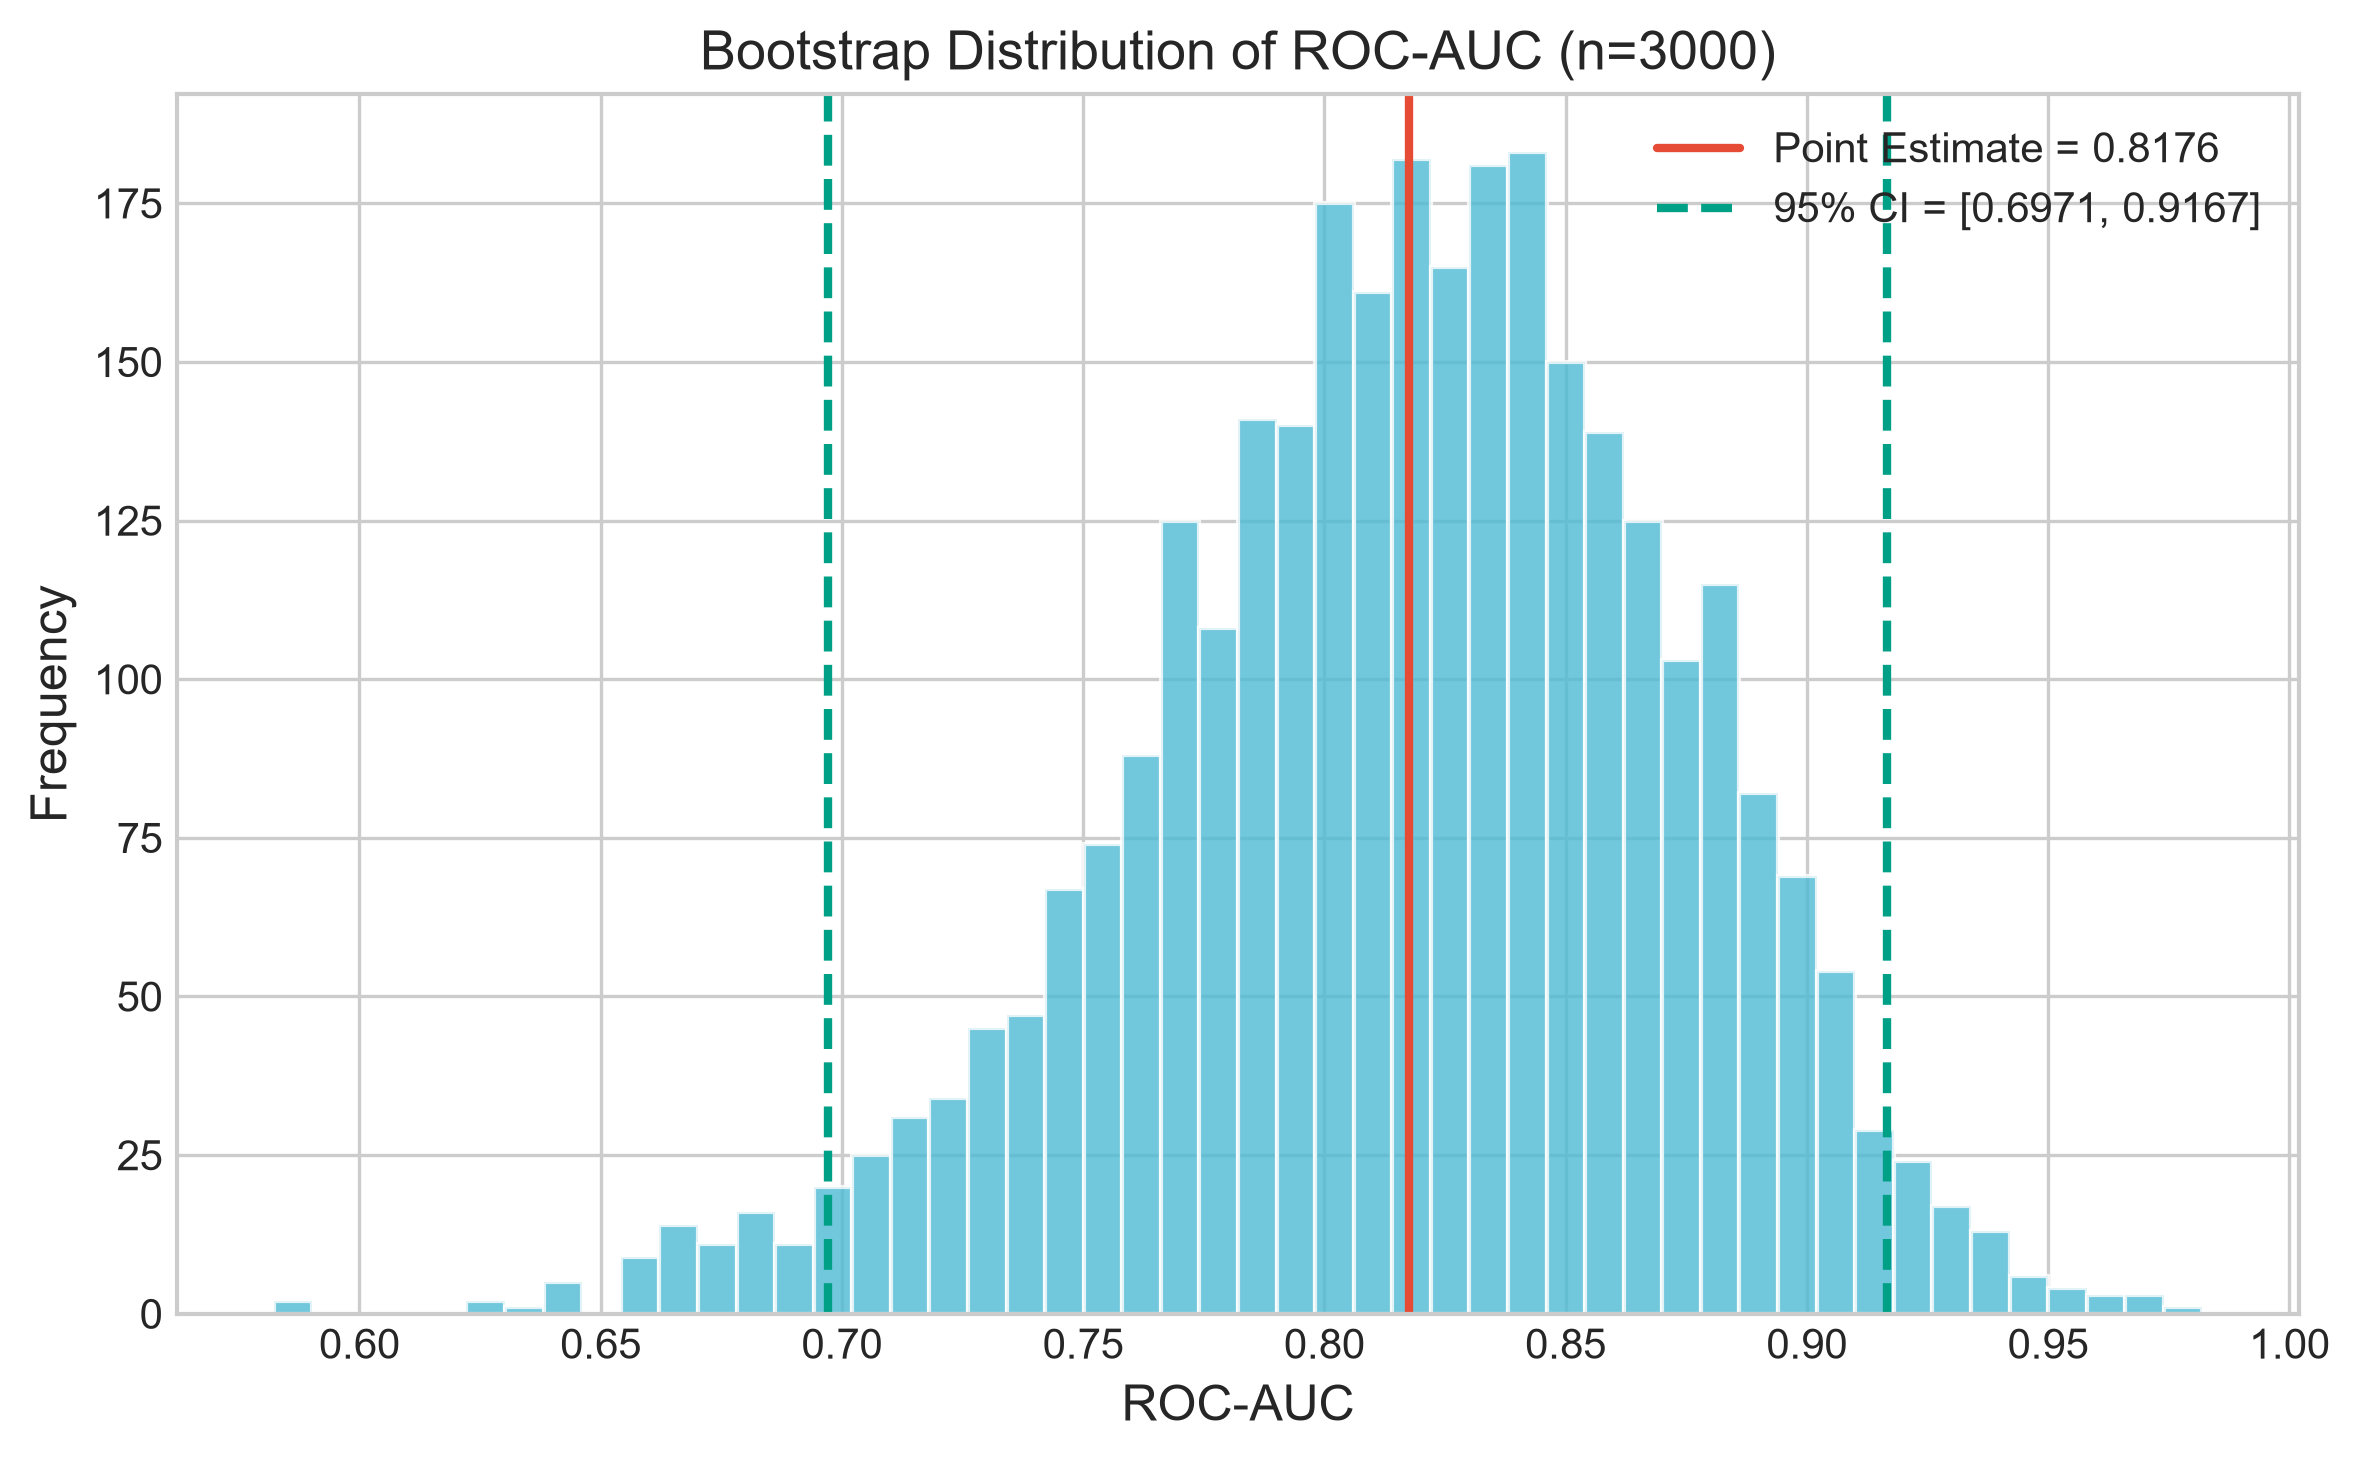

In [31]:
# Compute bootstrap CI for ROC-AUC
(ci_low, ci_high), bootstrap_scores = stratified_bootstrap_auc(
    y_test,
    y_prob,
    n_boot=config.BOOTSTRAP_N,
    random_state=config.RANDOM_STATE,
)

print(f"\nBootstrap 95% CI for ROC-AUC:")
print(f"  Point estimate: {metrics['roc_auc']:.4f}")
print(f"  95% CI:         [{ci_low:.4f}, {ci_high:.4f}]")
print(f"  Bootstrap samples: {len(bootstrap_scores)}")

# Visualize bootstrap distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(bootstrap_scores, bins=50, color="#4DBBD5", edgecolor="white", alpha=0.8)
ax.axvline(metrics["roc_auc"], color="#E64B35", linewidth=2, linestyle="-", label=f"Point Estimate = {metrics['roc_auc']:.4f}")
ax.axvline(ci_low, color="#00A087", linewidth=2, linestyle="--", label=f"95% CI = [{ci_low:.4f}, {ci_high:.4f}]")
ax.axvline(ci_high, color="#00A087", linewidth=2, linestyle="--")
ax.set_xlabel("ROC-AUC")
ax.set_ylabel("Frequency")
ax.set_title("Bootstrap Distribution of ROC-AUC (n=3000)")
ax.legend(framealpha=0.9)
plt.tight_layout()
save_figure(fig, "bootstrap_auc_distribution.png")
plt.show()

## Step 4: Publication-Quality Figures

Generate all figures for the manuscript at 300 DPI.

In [32]:
fig_roc = plot_roc_curve(
    y_test,
    y_prob,
    model_name=model_name,
    filename="final_roc_curve.png",
    figsize=(7, 6),
)
plt.show()

2026-08-06 01:50:24 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR_Q1\core\outputs\figures\final_roc_curve.png
2026-08-06 01:50:24 | INFO     | prostate_bcr | ROC curve plotted (AUC=0.8176)


In [33]:
fig_pr = plot_pr_curve(
    y_test,
    y_prob,
    model_name=model_name,
    filename="final_pr_curve.png",
    figsize=(7, 6),
)
plt.show()

2026-08-06 01:50:24 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR_Q1\core\outputs\figures\final_pr_curve.png
2026-08-06 01:50:24 | INFO     | prostate_bcr | PR curve plotted (PR-AUC=0.4682)


In [34]:
fig_cal = plot_calibration(
    y_test,
    y_prob,
    model_name=model_name,
    n_bins=10,
    filename="final_calibration_plot.png",
    figsize=(7, 6),
)
plt.show()

2026-08-06 01:50:24 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR_Q1\core\outputs\figures\final_calibration_plot.png
2026-08-06 01:50:24 | INFO     | prostate_bcr | Calibration plot generated


In [35]:
fig_cm = plot_confusion_matrix(
    y_test,
    y_pred,
    filename="final_confusion_matrix.png",
    figsize=(6, 5),
)
plt.show()

# Display confusion matrix as table
cm_df = pd.DataFrame(
    [[metrics["true_negative"], metrics["false_positive"]],
     [metrics["false_negative"], metrics["true_positive"]]],
    index=["Actual Negative", "Actual Positive"],
    columns=["Predicted Negative", "Predicted Positive"],
)
print("\nConfusion Matrix:")
print(cm_df.to_string())

2026-08-06 01:50:25 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR_Q1\core\outputs\figures\final_confusion_matrix.png
2026-08-06 01:50:25 | INFO     | prostate_bcr | Confusion matrix plotted



Confusion Matrix:
                 Predicted Negative  Predicted Positive
Actual Negative                  39                  35
Actual Positive                   1                  11


## Step 5: Save Final Results

Save all metrics and results to JSON and CSV for the manuscript.

In [36]:
# Prepare final results dictionary
final_results = {
    "model_name": model_name,
    "n_test_samples": int(len(y_test)),
    "n_positive": int(y_test.sum()),
    "n_negative": int((y_test == 0).sum()),
    "positive_rate": f"{y_test.mean():.2%}",
    "n_selected_features": len(selected_features),
    "metrics": {
        "roc_auc": round(metrics["roc_auc"], 4),
        "roc_auc_ci_low": round(ci_low, 4),
        "roc_auc_ci_high": round(ci_high, 4),
        "pr_auc": round(metrics["pr_auc"], 4),
        "accuracy": round(metrics["accuracy"], 4),
        "precision": round(metrics["precision"], 4),
        "recall": round(metrics["recall"], 4),
        "sensitivity": round(metrics["sensitivity"], 4),
        "specificity": round(metrics["specificity"], 4),
        "f1_score": round(metrics["f1"], 4),
        "mcc": round(metrics["mcc"], 4),
        "balanced_accuracy": round(metrics["balanced_accuracy"], 4),
    },
    "confusion_matrix": {
        "true_negative": metrics["true_negative"],
        "false_positive": metrics["false_positive"],
        "false_negative": metrics["false_negative"],
        "true_positive": metrics["true_positive"],
    },
}

# Save to JSON
with open(config.TABLES_DIR / "final_evaluation_results.json", "w", encoding="utf-8") as f:
    json.dump(final_results, f, ensure_ascii=False, indent=2)

# Save to CSV
results_df = pd.DataFrame([final_results["metrics"]])
results_df["model"] = model_name
save_table(results_df, "final_evaluation_metrics.csv", index=False)

print("Final results saved:")
print(f"  - final_evaluation_results.json")
print(f"  - final_evaluation_metrics.csv")
print("\nFinal Results Summary:")
print(json.dumps(final_results, ensure_ascii=False, indent=2))

2026-08-06 01:50:25 | INFO     | prostate_bcr | Saved 1 rows → D:\Prostate_BCR_Q1\core\outputs\tables\final_evaluation_metrics.csv


Final results saved:
  - final_evaluation_results.json
  - final_evaluation_metrics.csv

Final Results Summary:
{
  "model_name": "XGBoost + PSO",
  "n_test_samples": 86,
  "n_positive": 12,
  "n_negative": 74,
  "positive_rate": "13.95%",
  "n_selected_features": 30,
  "metrics": {
    "roc_auc": 0.8176,
    "roc_auc_ci_low": 0.6971,
    "roc_auc_ci_high": 0.9167,
    "pr_auc": 0.4682,
    "accuracy": 0.5814,
    "precision": 0.2391,
    "recall": 0.9167,
    "sensitivity": 0.9167,
    "specificity": 0.527,
    "f1_score": 0.3793,
    "mcc": 0.3082,
    "balanced_accuracy": 0.7218
  },
  "confusion_matrix": {
    "true_negative": 39,
    "false_positive": 35,
    "false_negative": 1,
    "true_positive": 11
  }
}


### Publication Outputs

All figures saved to `outputs/figures/` at 300 DPI:
- `final_roc_curve.png`
- `final_pr_curve.png`
- `final_calibration_plot.png`
- `final_confusion_matrix.png`
- `bootstrap_auc_distribution.png`

All tables saved to `outputs/tables/`:
- `final_evaluation_results.json`
- `final_evaluation_metrics.csv`
- `selected_features.csv`
- `feature_importance_full.csv`
- `biomarker_ranking_genes.csv`

---
